In [ ]:
"""
GRU Flood Forecasting Model (TensorFlow)
Predicts streamflow 24 hours (1 day) in advance using historical weather and streamflow data.
Target: streamflow_cfs_target_24h

Downloads preprocessed data from the W&B artifact produced by missouri_preprocessing.py
"""
import torch
import polars as pl
import wandb
import numpy as np
import joblib
from src.utils.preprocessing import processor

STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "start_date": "2007-10-28",
    "end_date": "2024-07-12",
    "file_path": "flood-dataset-missouri",
    "file_name": "flood_model_missouri",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-missouri:latest', 340.37MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.6 (574.0MB/s)


shape: (91,)
Series: 'site_id' [str]
[
	"06820500"
	"06893578"
	"06935770"
	"06900050"
	"06935850"
	…
	"06901500"
	"06932000"
	"06927240"
	"06904650"
	"06921200"
]
(11134405, 31)


In [2]:
WINDOW_SIZE = 36

def create_sequences(X, y, site_ids, window_size):
    """Create sliding window sequences per site.

    For each site, slides a window of `window_size` timesteps across the data.
    Each sequence uses `window_size` hours of features to predict the target
    at the last timestep.

    Returns:
        X_seq: array of shape (num_sequences, window_size, num_features)
        y_seq: array of shape (num_sequences,)
    """
    X_sequences, y_sequences = [], []
    unique_sites = np.unique(site_ids)

    for site in unique_sites:
        mask = site_ids == site
        site_X = X[mask]
        site_y = y[mask]

        timesteps = len(site_X)
        if timesteps <= window_size:
            continue

        num_windows = timesteps - window_size
        # Vectorised sliding-window indices: (num_windows, window_size)
        win_idx = np.arange(window_size)[None, :] + np.arange(num_windows)[:, None]

        X_sequences.append(site_X[win_idx])
        y_sequences.append(site_y[win_idx[:, -1]])

    return np.concatenate(X_sequences), np.concatenate(y_sequences)

In [3]:
np.random.seed(42)
SAMPLE_SITES = 30

REQUIRED_SITES = [
    "06926510", "06821250", "06927000", "06934000",
    "06910450", "06893500", "06893000"
]

all_sites = np.unique(train_X["site_id"].to_numpy())
remaining = [s for s in all_sites if s not in REQUIRED_SITES]
random_sites = np.random.choice(remaining, SAMPLE_SITES - len(REQUIRED_SITES), replace=False)
sampled_sites = np.array(REQUIRED_SITES + list(random_sites))
print(f"Using {len(sampled_sites)} sites ({len(REQUIRED_SITES)} required + {len(random_sites)} random)")

# Filter X and y together using a boolean mask (rows are aligned)
def filter_by_sites(X_df, y_df, sites):
    mask = X_df["site_id"].is_in(sites).to_numpy()
    return X_df.filter(pl.Series(mask)), y_df.filter(pl.Series(mask))

train_X_s, train_y_s = filter_by_sites(train_X, train_y, sampled_sites)
val_X_s, val_y_s = filter_by_sites(val_X, val_y, sampled_sites)
test_X_s, test_y_s = filter_by_sites(test_X, test_y, sampled_sites)

# Extract site ids and numpy arrays
train_sites = train_X_s["site_id"].to_numpy()
val_sites = val_X_s["site_id"].to_numpy()
test_sites = test_X_s["site_id"].to_numpy()

drop_cols = ["site_id", "observation_hour"]
train_X_arr = train_X_s.drop(drop_cols).to_numpy()
val_X_arr = val_X_s.drop(drop_cols).to_numpy()
test_X_arr = test_X_s.drop(drop_cols).to_numpy()
train_y_arr = train_y_s.to_numpy().flatten()
val_y_arr = val_y_s.to_numpy().flatten()
test_y_arr = test_y_s.to_numpy().flatten()

print("\nCreating sequences...")
X_train, y_train = create_sequences(train_X_arr, train_y_arr, train_sites, WINDOW_SIZE)
X_val, y_val = create_sequences(val_X_arr, val_y_arr, val_sites, WINDOW_SIZE)
X_test, y_test = create_sequences(test_X_arr, test_y_arr, test_sites, WINDOW_SIZE)

def drop_nan_rows(X, y):
    nan_x = np.isnan(X).any(axis=(1, 2))
    nan_y = np.isnan(y)
    mask = ~(nan_x | nan_y)
    return X[mask], y[mask]

before = len(X_train)
X_train, y_train = drop_nan_rows(X_train, y_train)
X_val, y_val = drop_nan_rows(X_val, y_val)
X_test, y_test = drop_nan_rows(X_test, y_test)
print(f"Dropped {before - len(X_train)} NaN rows from train")

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

Using 30 sites (7 required + 23 random)

Creating sequences...
Dropped 388447 NaN rows from train
X_train: (2061291, 36, 28)  y_train: (2061291,)
X_val:   (245066, 36, 28)  y_val:   (245066,)
X_test:  (245751, 36, 28)  y_test:  (245751,)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

In [5]:
DROPOUT_RATE = 0.3
UNDER_PREDICT_PENALTY = 2.0

def asymmetric_mse(y_true, y_pred):
    """MSE loss that penalizes under-predictions more heavily.
    
    When pred < actual (under-prediction), the loss is multiplied by
    UNDER_PREDICT_PENALTY. This biases the model toward reading high,
    which is safer for flood forecasting.
    """
    error = y_true - y_pred
    weight = tf.where(error > 0, UNDER_PREDICT_PENALTY, 1.0)
    return tf.reduce_mean(weight * tf.square(error))

model = Sequential([
    GRU(32, return_sequences=True),
    Dropout(DROPOUT_RATE),
    GRU(16, return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(64),
    Dense(1)
])

model.compile(optimizer='adam', loss=asymmetric_mse, metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

def make_dataset(X, y, batch_size=512, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        X.astype(np.float32), 
        y.astype(np.float32)
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds = make_dataset(X_val, y_val)

history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 89s 21ms/step - loss: 0.5846 - mae: 0.2176 - val_loss: 1.9352 - val_mae: 0.6148
Epoch 2/50
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 90s 22ms/step - loss: 0.5210 - mae: 0.1880 - val_loss: 1.5694 - val_mae: 0.5841
Epoch 3/50
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 77s 19ms/step - loss: 0.4804 - mae: 0.1754 - val_loss: 1.7529 - val_mae: 0.4986
Epoch 4/50
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 74s 18ms/step - loss: 0.4275 - mae: 0.1663 - val_loss: 1.8049 - val_mae: 0.4529
Epoch 5/50
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 74s 18ms/step - loss: 0.4426 - mae: 0.1637 - val_loss: 1.9528 - val_mae: 0.4808
Epoch 6/50
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 74s 18ms/step - loss: 0.4296 - mae: 0.1609 - val_loss: 1.3679 - val_mae: 0.3479
Epoch 7/50
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 73s 18ms/step - loss: 0.3963 - mae: 0.1566 - val_loss: 1.2197 - val_mae: 0.3131
Epoch 8/50
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 76s 19ms/step - loss: 0.3824 - mae: 0.1547 - val_loss: 1.2259 - val_mae: 0.3072
Epoch 9/50
4026/4026 ━━━

In [9]:

pythonpred_test = model.predict(X_test, verbose=0).flatten()

pred_test_real = pcr.target_scaler.inverse_transform(
    torch.tensor(pythonpred_test).reshape(-1, 1)
).numpy().flatten()
actual_test_real = pcr.target_scaler.inverse_transform(
    torch.tensor(y_test).reshape(-1, 1)
).numpy().flatten()

mae = np.abs(pred_test_real - actual_test_real).mean()
rmse = np.sqrt(np.mean((pred_test_real - actual_test_real) ** 2))
nse = 1 - (np.sum((actual_test_real - pred_test_real) ** 2) / 
           np.sum((actual_test_real - actual_test_real.mean()) ** 2))

print(f"{'Metric':<10} {'Value':>10}")
print(f"{'-'*22}")
print(f"{'MAE':<10} {mae:>8.1f} CFS")
print(f"{'RMSE':<10} {rmse:>8.1f} CFS")
print(f"{'NSE':<10} {nse:>10.4f}")
print(f"\nActual mean:    {actual_test_real.mean():.1f} CFS")
print(f"Predicted mean: {pred_test_real.mean():.1f} CFS")

Metric          Value
----------------------
MAE           619.4 CFS
RMSE         2203.4 CFS
NSE            0.3069

Actual mean:    584.8 CFS
Predicted mean: 798.6 CFS


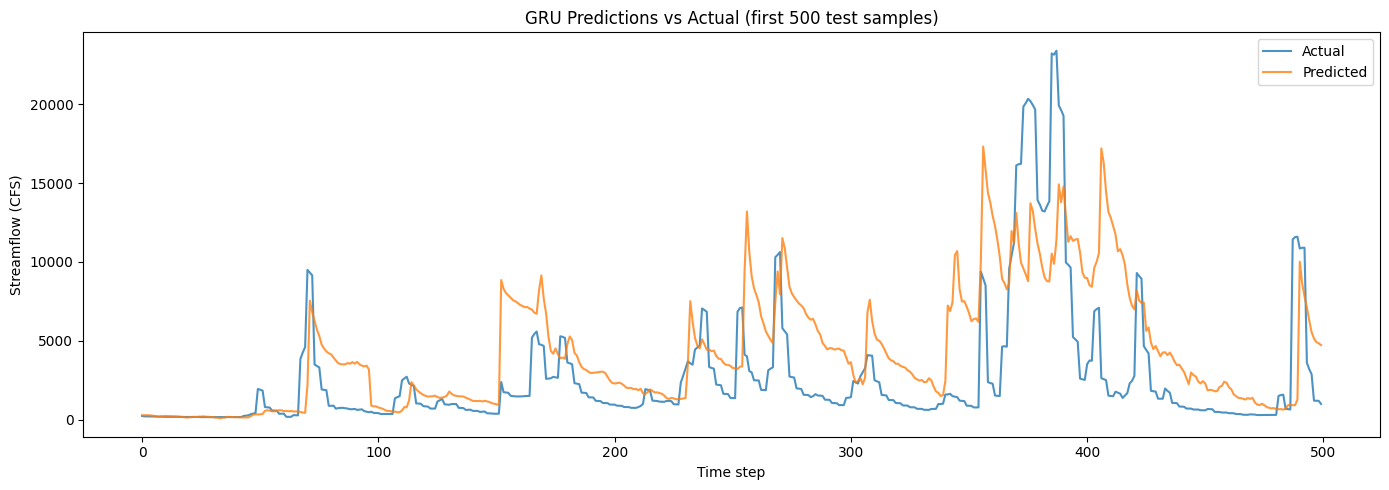

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(actual_test_real[:500], label="Actual", alpha=0.8)
ax.plot(pred_test_real[:500], label="Predicted", alpha=0.8)
ax.set_xlabel("Time step")
ax.set_ylabel("Streamflow (CFS)")
ax.set_title("GRU Predictions vs Actual (first 500 test samples)")
ax.legend()
plt.tight_layout()
plt.savefig("gru_baseline_predictions.png", dpi=300, bbox_inches='tight')
plt.show()